In [2]:
import pandas as pd  #data manipulation
import numpy as np    # numerical operations

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)   #see all columns
sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("../data/eda/eda1.csv")
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7032, 20)

# Univariate Analysis

## Numerical Features

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


here four features shows. but we know `SeniorCitizen` is categorical feature(true or false). so first lets analyse other three features.

In [6]:
numerical_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

array([[<Axes: title={'center': 'tenure'}>,
        <Axes: title={'center': 'MonthlyCharges'}>],
       [<Axes: title={'center': 'TotalCharges'}>, <Axes: >]], dtype=object)

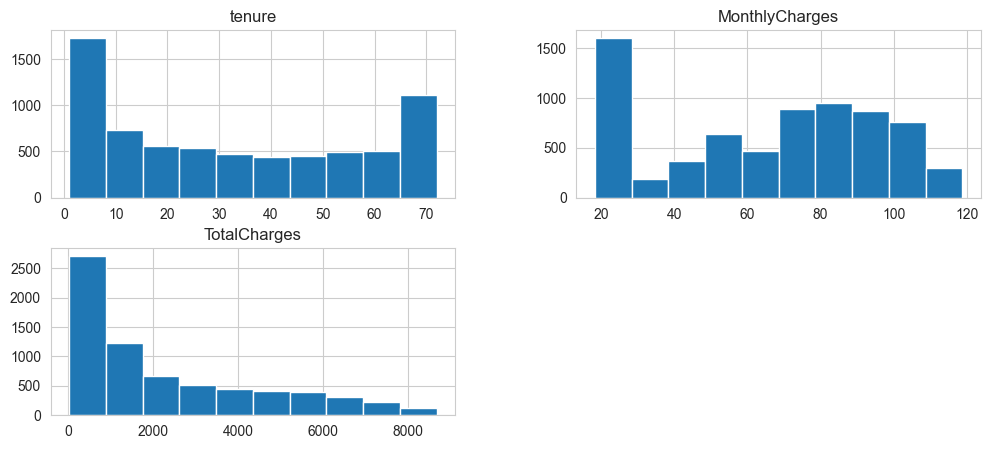

In [7]:
df[numerical_cols].hist(figsize=(12,5))

#### So most of my assumptions were correct. but here we have to get few key insights

In [8]:
df.shape

(7032, 20)

#### in tenure
- there are around 25% new customers. this is very very important feature for churn and new customers are most likely to churn. 
- by the way they also have around 30-40% percent loyal customers. (i measured it using threshold more than 50 months)
- In between range there probability of churning is low. also in this range customers are evenly distibuted.

### in monthlyCharges
- it seems to be have normal distribution except for 10-30$ (first bar). 
- around 20-25% percent customers are in lowest price packages (first bar)


#### TotalCharges
- this simply has skewed dataset. that means `monthlyCharges` of most of the customers are not expensive
- more than 50% percent customers spend less than **2000$ monthly**. so we have to keep that in mind
- for expensive pricing we have to think about other data, because if customer is new and they not satisfy with this high pricing then there is higher probability to loss them.

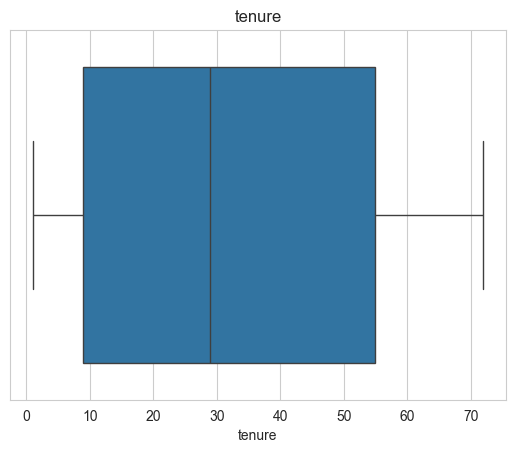

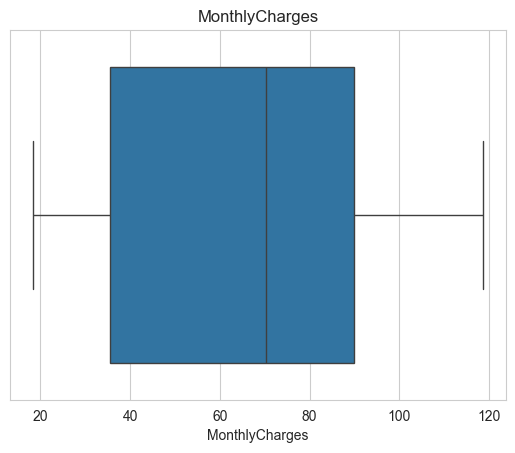

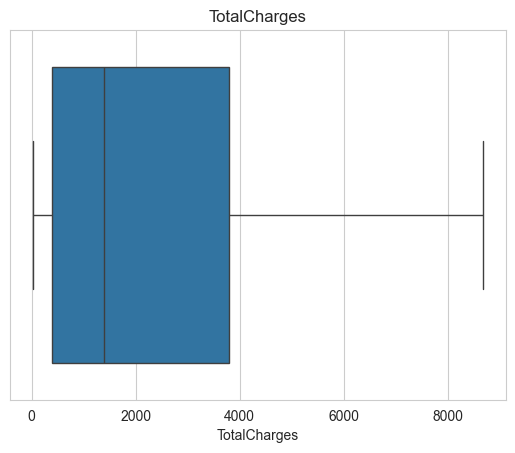

In [9]:
for col in numerical_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

## Categorical Analysis

In [10]:
categorical_cols = df.select_dtypes(include="object").columns

In [11]:
categorical_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

### Contacts Feature

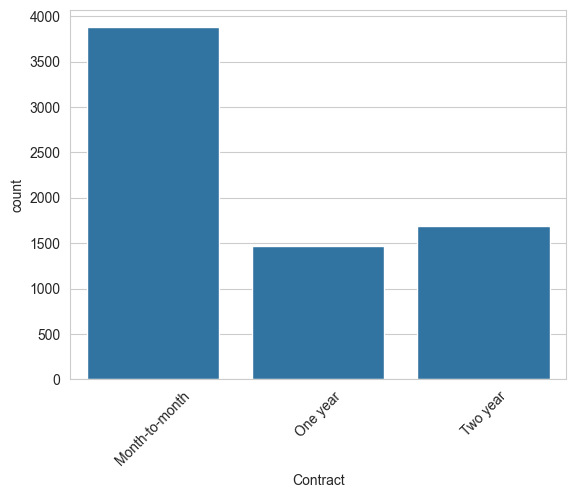

In [12]:
sns.countplot(data=df, x="Contract")
plt.xticks(rotation=45)
plt.show()

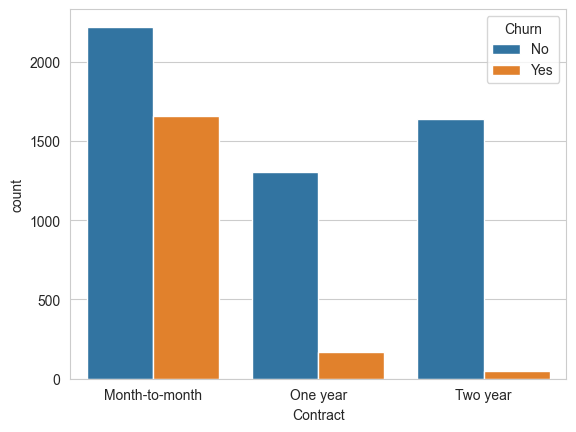

In [13]:
sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)
plt.show()

**Here we can clearly see that customers with `month-to-month` contacts are more likely to churn.**

### Internet Service

<Axes: xlabel='InternetService', ylabel='count'>

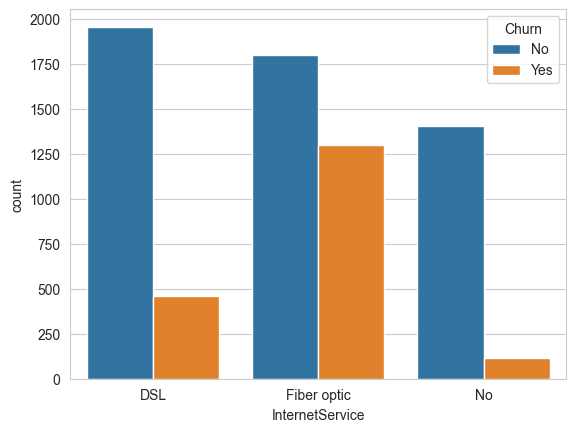

In [15]:
sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

### Payment Method

<Axes: xlabel='PaymentMethod', ylabel='count'>

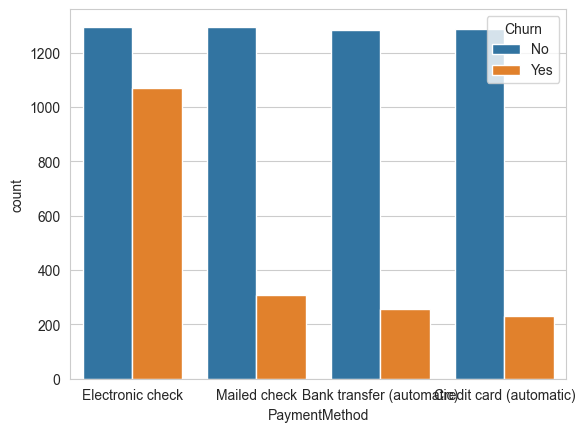

In [16]:
sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

**Here most important thing is other three options except **Electronic check** has similararity. there exception is customers  that use Electronic Check payment method. They are more likely to churn. nearly half of customers churns in that category.**

### Online Security

<Axes: xlabel='OnlineSecurity', ylabel='count'>

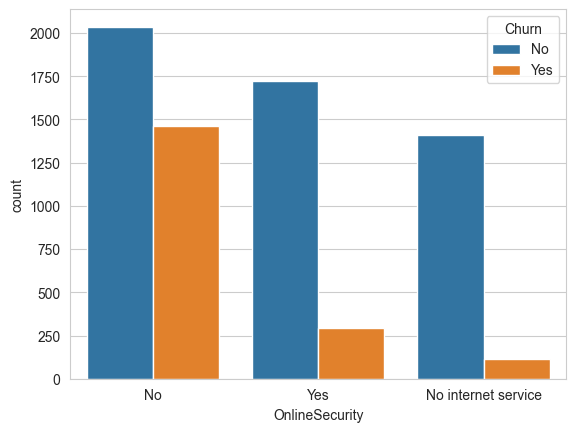

In [17]:
sns.countplot(
    data=df,
    x="OnlineSecurity",
    hue="Churn"
)

if customer use internet service they need online security. if they not get `OnlineSecurity` they likely to churn

### Tech Support

<Axes: xlabel='TechSupport', ylabel='count'>

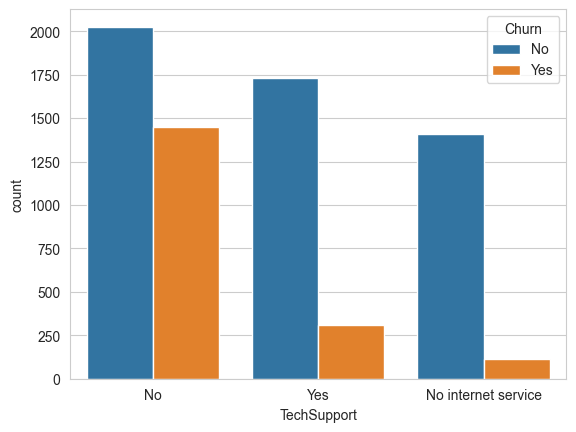

In [18]:
sns.countplot(
    data=df,
    x="TechSupport",
    hue="Churn"
)

**Same as for `OnlineSecurity`**

<Axes: xlabel='SeniorCitizen', ylabel='count'>

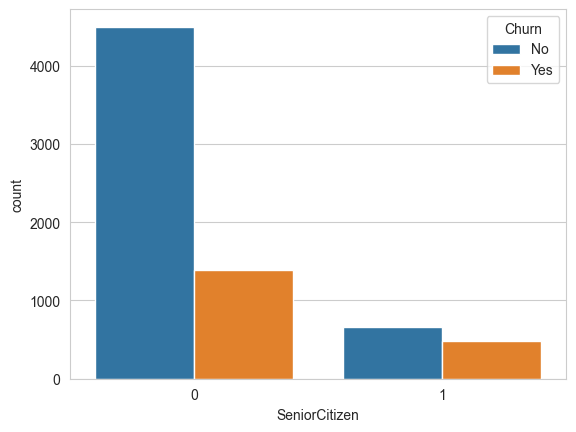

In [19]:
sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

*There are very few senior citizens, but there churn rate is higher. i think they not align with modern technology so that is why they likely to churn*

### Partner

<Axes: xlabel='Partner', ylabel='count'>

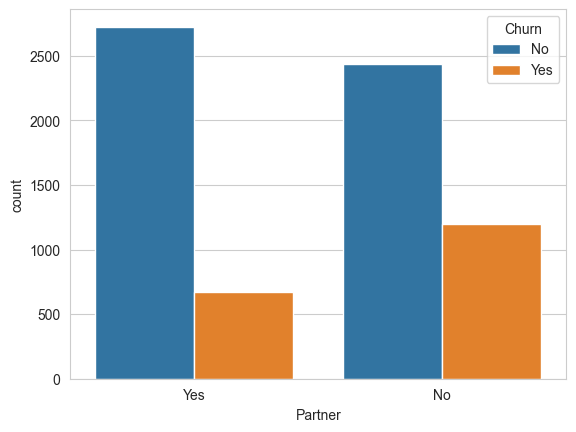

In [21]:
sns.countplot(
    data=df,
    x="Partner",
    hue="Churn"
)

cant get proper idea directly. can be feature that related to this dataset only

### Dependents

<Axes: xlabel='Dependents', ylabel='count'>

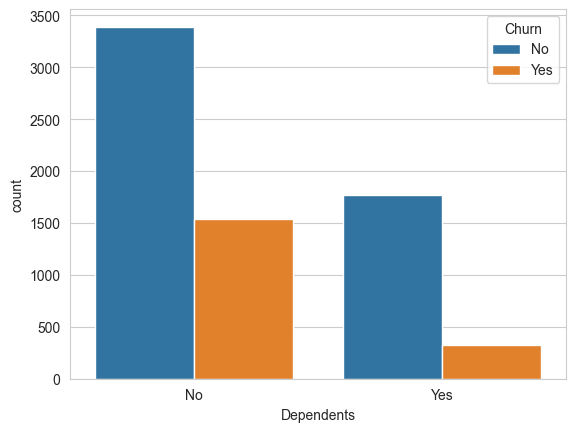

In [22]:
sns.countplot(
    data=df,
    x="Dependents",
    hue="Churn"
)

In [26]:
categorical_cols


Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

### Gender

<Axes: xlabel='gender', ylabel='count'>

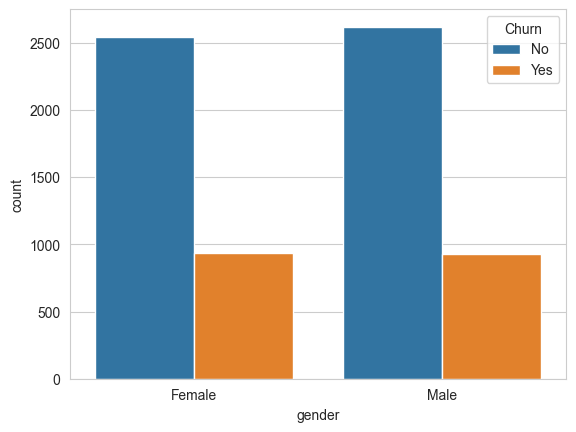

In [28]:
sns.countplot(
    data=df,
    x="gender",
    hue="Churn"
)

**Gender has no isignificant nfluence on churn rate**

### Phone Service

<Axes: xlabel='PhoneService', ylabel='count'>

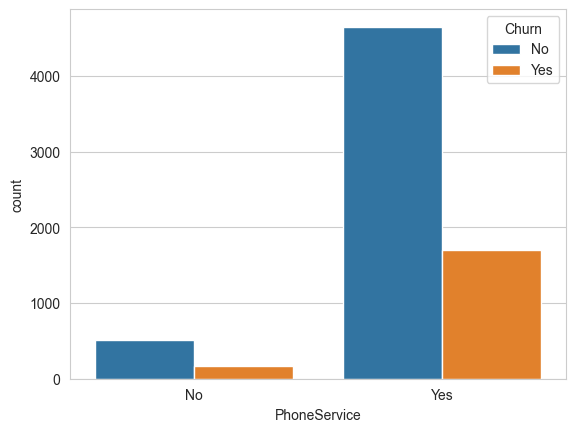

In [30]:
sns.countplot(
    data=df,
    x="PhoneService",
    hue="Churn"
)

cant get clear idea

### Multiple Lines

<Axes: xlabel='MultipleLines', ylabel='count'>

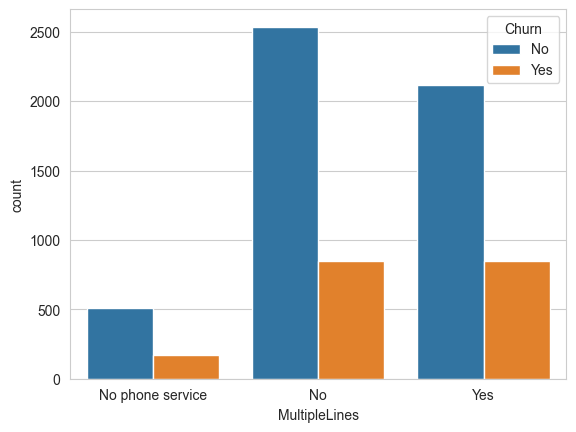

In [32]:
sns.countplot(
    data=df,
    x="MultipleLines",
    hue="Churn"
)

no clear insight

### Online Backup

<Axes: xlabel='OnlineBackup', ylabel='count'>

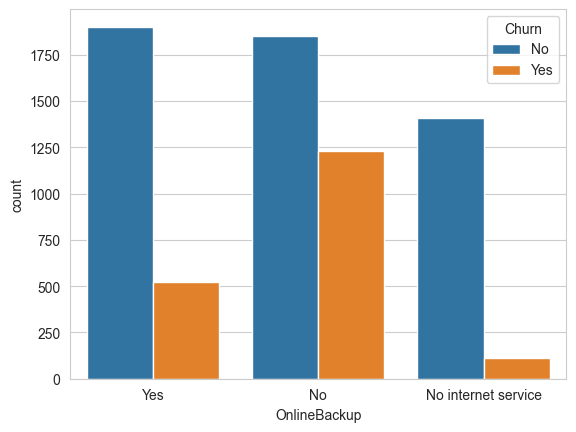

In [33]:
sns.countplot(
    data=df,
    x="OnlineBackup",
    hue="Churn"
)

**here we can see that customers that dont have no online backup (that has internetService) are more likely to churn**

### Device Protection

<Axes: xlabel='DeviceProtection', ylabel='count'>

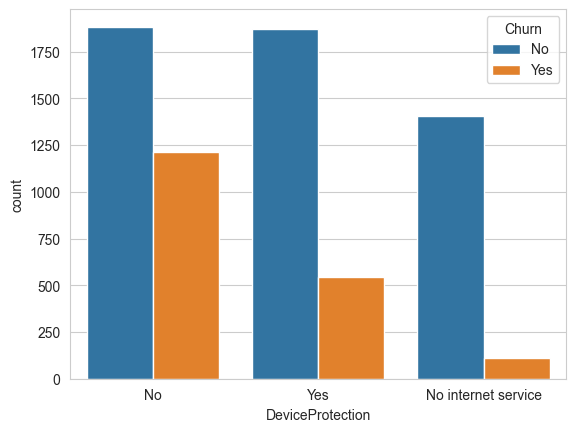

In [34]:
sns.countplot(
    data=df,
    x="DeviceProtection",
    hue="Churn"
)

### StreamingTV

<Axes: xlabel='StreamingTV', ylabel='count'>

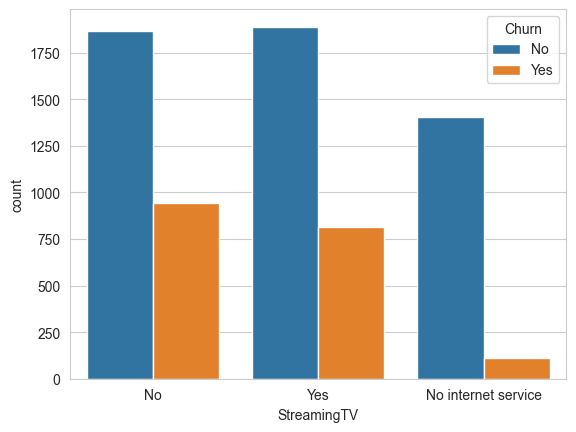

In [35]:
sns.countplot(
    data=df,
    x="StreamingTV",
    hue="Churn"
)

### StreamingMovies

<Axes: xlabel='StreamingMovies', ylabel='count'>

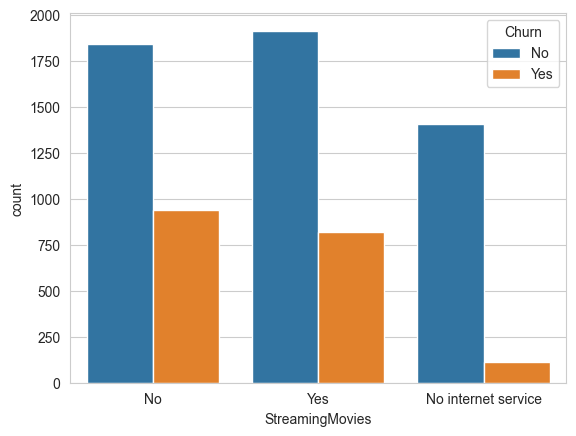

In [36]:
sns.countplot(
    data=df,
    x="StreamingMovies",
    hue="Churn"
)

### PaperlessBilling

<Axes: xlabel='PaperlessBilling', ylabel='count'>

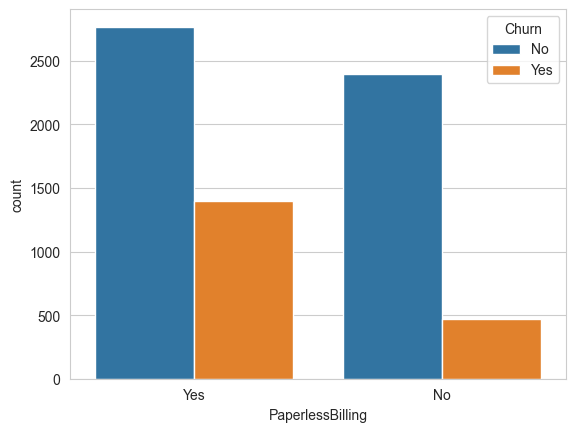

In [37]:
sns.countplot(
    data=df,
    x="PaperlessBilling",
    hue="Churn"
)

# Bivariate Analysis

### Churn vs Tenure

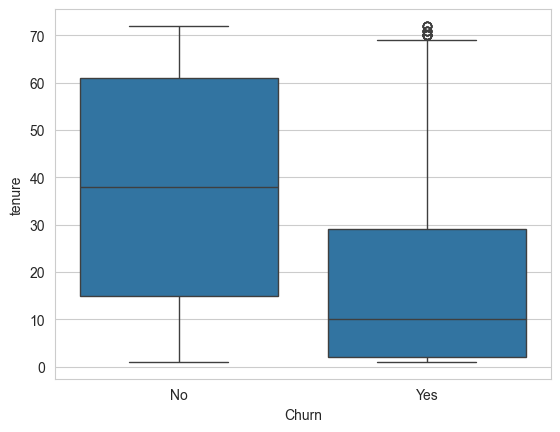

In [23]:
sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)
plt.show()

here we can clearly see that new customers leaves quickly. **very few outliers that old customers churning**. so this is good insight.

### Churn vs Monthly Charges

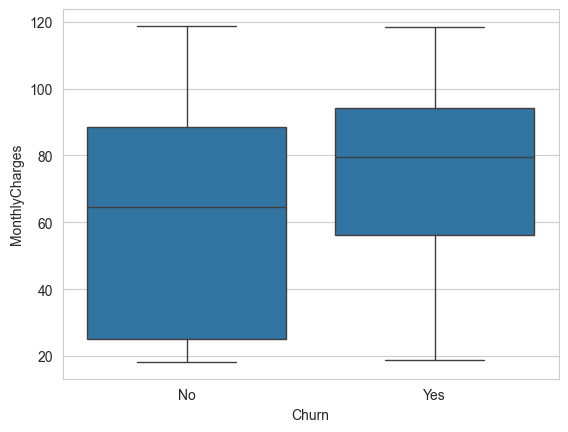

In [25]:
sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)
plt.show()

**There is high probability of churning of customers that has higher monthly charges**

## Churn rate per category

In [ ]:
for col in (categorical_cols):
    
    pd.crosstab(
        df[col],
        df["Churn"],
        normalize="index"
    ) * 100
    

In [41]:
df.to_csv(index=False, path_or_buf="../data/eda/eda2.csv")

In [44]:
df.shape

(7032, 21)